In [49]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [50]:
X = pd.read_csv("Fromage.csv",delimiter=";", decimal=".")
#X.dtypes
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Fromages     29 non-null     object 
 1   Calories     29 non-null     int64  
 2   Sodium       29 non-null     float64
 3   Calcium      29 non-null     float64
 4   Lipides      29 non-null     float64
 5   Retinol      29 non-null     float64
 6   Folates      29 non-null     float64
 7   Proteines    29 non-null     float64
 8   Cholesterol  29 non-null     int64  
 9   Magnesium    29 non-null     int64  
 10  Type         29 non-null     object 
dtypes: float64(6), int64(3), object(2)
memory usage: 2.6+ KB


In [51]:
# 29 individus et 10variables

# 29: très faible. On "estime" au moins 10 observations par variable indépendante donc ici : 100individus peuvent être nécessaires pour englober la diversité des paramètres.

#La réduction de dimension est nécessaire, même si la variance n'est pas fortement expliquée (60% OK)

In [52]:
X = X.set_index(['Fromages'])

import numpy as np

X.head()


,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium,Type
Fromages,,,,,,,,,,
CarreDelEst,314,353.5,72.6,26.3,51.6,30.3,21.0,70,20,pate molle
Babybel,314,238.0,209.8,25.1,63.7,6.4,22.6,70,27,pate pressee noncuite
Beaufort,401,112.0,259.4,33.3,54.9,1.2,26.6,120,41,pate pressee cuite
Bleu,342,336.0,211.1,28.9,37.1,27.5,20.2,90,27,pate molle
Camembert,264,314.0,215.9,19.5,103.0,36.4,23.4,60,20,pate molle


In [53]:
X1 = X.select_dtypes(exclude=['object'])

X1.head()

,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium
Fromages,,,,,,,,,
CarreDelEst,314,353.5,72.6,26.3,51.6,30.3,21.0,70,20
Babybel,314,238.0,209.8,25.1,63.7,6.4,22.6,70,27
Beaufort,401,112.0,259.4,33.3,54.9,1.2,26.6,120,41
Bleu,342,336.0,211.1,28.9,37.1,27.5,20.2,90,27
Camembert,264,314.0,215.9,19.5,103.0,36.4,23.4,60,20


In [54]:
# On standardise avec standardScaler

In [55]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Z = StandardScaler().fit_transform(X1)
Z1 = pd.DataFrame(data = Z, columns = X1.columns,index=X.index)
Z1.head()

,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium
Fromages,,,,,,,,,
CarreDelEst,0.154630,1.342968,-1.587464,0.268066,-0.672290,1.500911,0.121519,-0.165242,-0.626309
Babybel,0.154630,0.261393,0.337679,0.117846,-0.162662,-0.573843,0.355480,-0.165242,0.003101
Beaufort,1.117917,-0.918507,1.033649,1.144354,-0.533301,-1.025253,0.940383,1.636269,1.261920
Bleu,0.464654,1.179093,0.355920,0.593544,-1.283000,1.257844,0.004538,0.555362,0.003101
Camembert,-0.398983,0.973078,0.423272,-0.583184,1.492574,2.030451,0.472461,-0.525544,-0.626309


In [56]:
# on va réduire les dimensions

In [57]:
import sklearn as sk

In [58]:
from sklearn.decomposition import PCA

In [59]:
print(PCA)

<class 'sklearn.decomposition._pca.PCA'>


In [60]:
acp=PCA(svd_solver='full')
print(acp)

PCA(svd_solver='full')


In [61]:
coord=acp.fit_transform(Z1)

In [62]:
print(coord)

[[-6.41901181e-01  1.80278717e+00 -1.50744108e+00 -5.94272332e-01
   9.75072008e-01  2.06673788e-01  5.23195251e-01  2.72996812e-02
  -5.33244680e-02]
 [ 4.72444914e-01 -3.33175728e-01 -2.47079740e-01  3.99021308e-01
  -1.98051110e-01  2.78605400e-01  1.82601147e-01 -1.57864544e-01
  -6.81283146e-05]
 [ 2.92868343e+00 -1.04937541e+00  5.56448441e-01 -8.47559684e-01
  -1.63629989e-01 -1.18782260e-01 -4.50192328e-01  9.58075573e-02
  -4.42561880e-02]
 [ 7.63344866e-01  6.92700423e-01 -1.34325923e+00  6.83844833e-03
   1.52541913e+00 -3.50438536e-01 -5.51642136e-01 -1.86233960e-02
  -2.38144474e-02]
 [-9.74337165e-01  1.92635759e+00  8.03938671e-01  1.39395135e+00
   1.04032561e+00  5.87553636e-01 -3.89771074e-01  1.91054337e-01
  -4.46534089e-02]
 [ 1.64673594e+00 -6.21675715e-01 -6.23102641e-01  3.70700959e-01
   1.52968238e-01  2.98132241e-02 -4.08840902e-01 -1.58030621e-01
   1.39127137e-01]
 [-2.11594698e-01  2.08746096e+00  9.74470922e-01 -1.18946238e+00
   8.34488440e-01 -6.4983732

In [63]:
print(acp.explained_variance_ratio_)

[5.61012646e-01 2.04935374e-01 9.64223245e-02 6.41538526e-02
 3.94677950e-02 1.94790658e-02 1.08260237e-02 3.15901368e-03
 5.43905072e-04]


In [64]:
# On a 76% de variance expliquée sur 2 axes. 86% sur 3 axes

In [65]:
# Les Valeurs propres
eigval = acp.explained_variance_
print([eigval])

[array([5.22943931e+00, 1.91029045e+00, 8.98793811e-01, 5.98005554e-01,
       3.67896232e-01, 1.81572721e-01, 1.00914007e-01, 2.94465204e-02,
       5.06997228e-03])]


In [66]:
# on compare au cutoff de Saporta (1+ sqrt(p-1/n-1))
# On devrait garder 2 facteurs pour un modèle cohérent réduit. On garde 3CP pour le clustering 

9


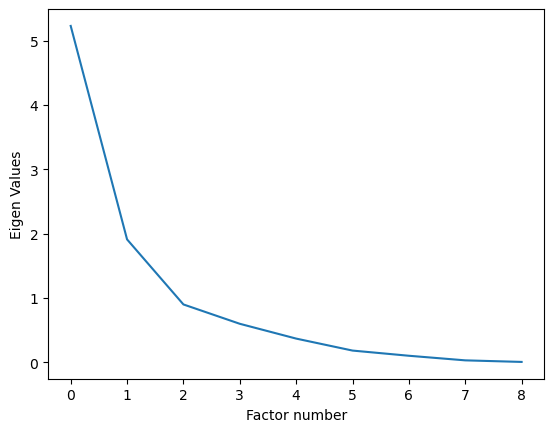

In [67]:
#nombre de variables
p = X1.shape[1]
print(p)
#nombre d'observations
n = X1.shape[0]
#matrice des X
X = X1.values

import matplotlib.pyplot as plt
plt.plot(np.arange(p),eigval)
plt.ylabel("Eigen Values")
plt.xlabel("Factor number")
plt.show()

In [68]:
acp=PCA(n_components=3,svd_solver='full')
coord=acp.fit_transform(Z1)
print(coord)

[[-0.64190118  1.80278717 -1.50744108]
 [ 0.47244491 -0.33317573 -0.24707974]
 [ 2.92868343 -1.04937541  0.55644844]
 [ 0.76334487  0.69270042 -1.34325923]
 [-0.97433717  1.92635759  0.80393867]
 [ 1.64673594 -0.62167571 -0.62310264]
 [-0.2115947   2.08746096  0.97447092]
 [-0.91401635  2.48800307  0.99455353]
 [ 1.90350409  0.32790356  0.24328567]
 [ 3.18010053 -1.02494321  0.99072899]
 [-0.84085401  1.13460546 -0.8291479 ]
 [ 1.51773013 -1.16291493  1.04301532]
 [ 2.8769626  -1.6743823   1.31432681]
 [-3.16826783  2.55883531  2.09783738]
 [-0.25554034  0.74898345 -1.15760427]
 [-4.80124463 -1.8248518   0.17172799]
 [-4.56033385 -0.91187992  0.36553568]
 [ 1.72874008 -0.56232493 -0.80311727]
 [ 1.3001583  -0.12510373 -0.63114768]
 [ 2.95797824 -0.33655568  1.62703772]
 [-4.33410754 -0.85041934  0.29082747]
 [-0.10194023 -0.48660443 -0.80492304]
 [ 0.92593866 -0.16244703 -0.79595637]
 [ 0.4583152   0.09407671 -0.14274305]
 [ 1.07365199  1.9028249  -1.11224563]
 [ 0.48172727 -0.87153227

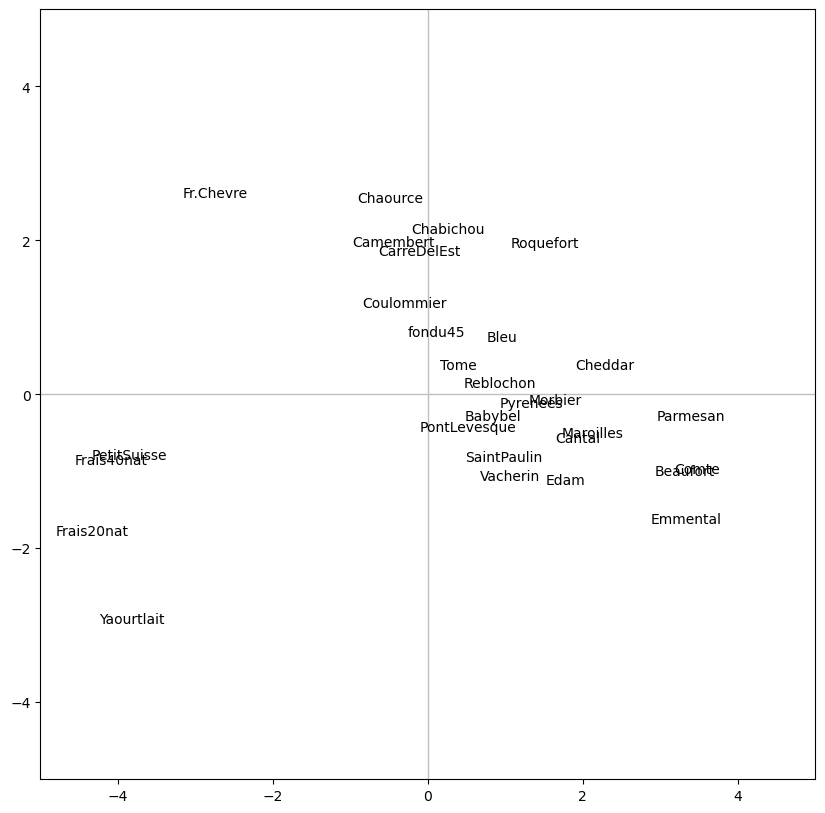

In [69]:

f,ax = plt.subplots(figsize=(10,10))
#fig, axes = plt.plot(figsize=(10,10))
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
n = X1.shape[0]

for i in range(n):
    plt.annotate(X1.index[i],(coord[i,0],coord[i,1]))
plt.plot([-5,5],[0,0],color='silver',linestyle='-',linewidth=1)
plt.plot([0,0],[-5,5],color='silver',linestyle='-',linewidth=1)
plt.show()

In [70]:
# On va regarder KMeans sur " CP"

In [163]:
from sklearn.cluster import KMeans
from sklearn import metrics 

#sklearn.cluster.KMeans(n_clusters=???, init='k-means++', n_init='auto', max_iter=300, random_state=None)

res=[] 
wcss=[]

range_n_cluster = range(2,10)
for k in range_n_cluster:  
    km = KMeans(n_clusters=k, n_init=20,max_iter=500) 
    km.fit(coord) 
    res.append(metrics.silhouette_score(coord,km.labels_) )
    wcss.append(km.inertia_)

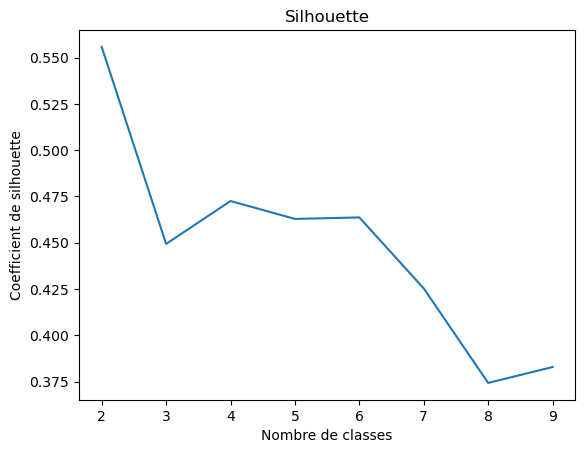

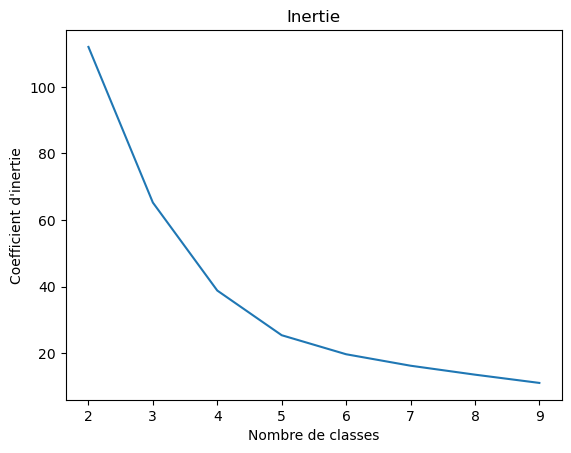

In [164]:
#plot nb. clusters vs. silhouette score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,10,1),res) 
plt.title("Silhouette")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient de silhouette")
plt.show() 

#plot nb. clusters vs. Inertie score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,10,1),wcss) 
plt.title("Inertie")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient d'inertie")
plt.show() 

In [79]:
# On peut essayer 4 clusters

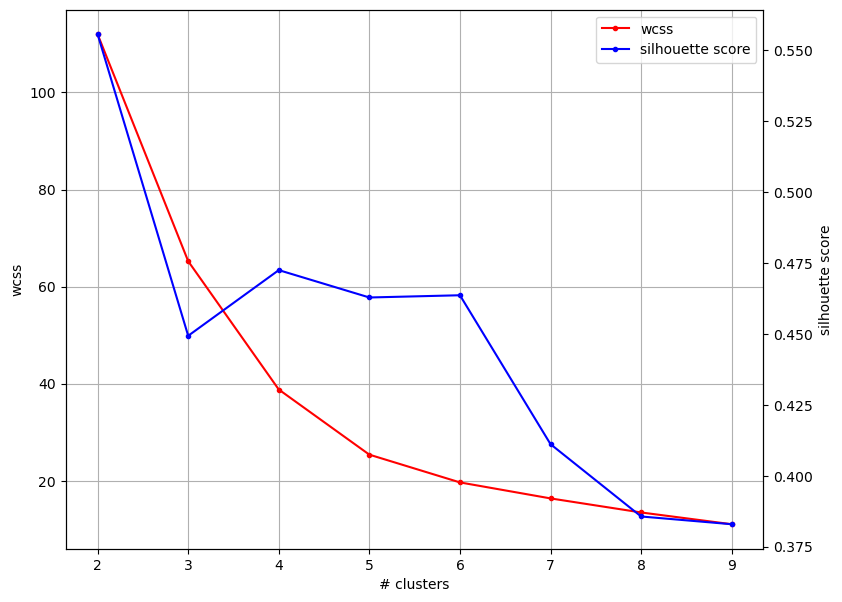

In [80]:
figsize=(9, 7)
res=[] 
wcss=[]
clusters_range = range(2,10)
for k in clusters_range:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300)
    km.fit(coord)
    wcss.append(km.inertia_)
    res.append(metrics.silhouette_score(coord,km.labels_) )
_, ax1 = plt.subplots(figsize=figsize)
  
ax1.plot(clusters_range, wcss, label="wcss", color="red", marker=".")
ax1.set_xlabel("# clusters")
ax1.set_ylabel("wcss")
ax1.grid(True)
    
ax2 = plt.gca().twinx()
ax2.plot(clusters_range, res, label="silhouette score", color="blue", marker=".")
ax2.set_ylabel("silhouette score")

g1, gl1 = ax1.get_legend_handles_labels()
g2, gl2 = ax2.get_legend_handles_labels()
plt.legend(g1 + g2, gl1 + gl2)

plt.show()

In [174]:
km = KMeans(n_clusters=4) 
km.fit(coord) 

cluster_labels = km.predict(coord)


In [175]:
from sklearn.metrics import silhouette_score
score=silhouette_score(coord,cluster_labels)
score

np.float64(0.4725347353908354)

In [176]:
num_clusters=4
sample_silhouette_values = metrics.silhouette_samples(coord, km.labels_)

moy_Score_cluster = []
for i in range(num_clusters):
    moy_Score_cluster.append(sample_silhouette_values[km.labels_ == i].mean())
print(moy_Score_cluster)

[np.float64(0.47943093852088614), np.float64(0.7413306478017634), np.float64(0.38768745261836535), np.float64(0.5115718286815945)]


In [177]:
# 2 clusters bien distingués sur 4 

In [85]:
# Ici on va annoter tous les fromages

In [178]:
cluster_count = 4
km = KMeans(n_clusters=cluster_count, n_init=20, max_iter=100) 
km.fit(coord) 
km.labels_
cluster_labels = km.fit_predict(coord)
cluster_labels


df_clustered=X1.copy()
df_clustered=pd.DataFrame(df_clustered)
df_clustered["cluster"]=cluster_labels
df_clustered.head()

,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium,cluster
Fromages,,,,,,,,,,
CarreDelEst,314,353.5,72.6,26.3,51.6,30.3,21.0,70,20,1
Babybel,314,238.0,209.8,25.1,63.7,6.4,22.6,70,27,1
Beaufort,401,112.0,259.4,33.3,54.9,1.2,26.6,120,41,0
Bleu,342,336.0,211.1,28.9,37.1,27.5,20.2,90,27,1
Camembert,264,314.0,215.9,19.5,103.0,36.4,23.4,60,20,3


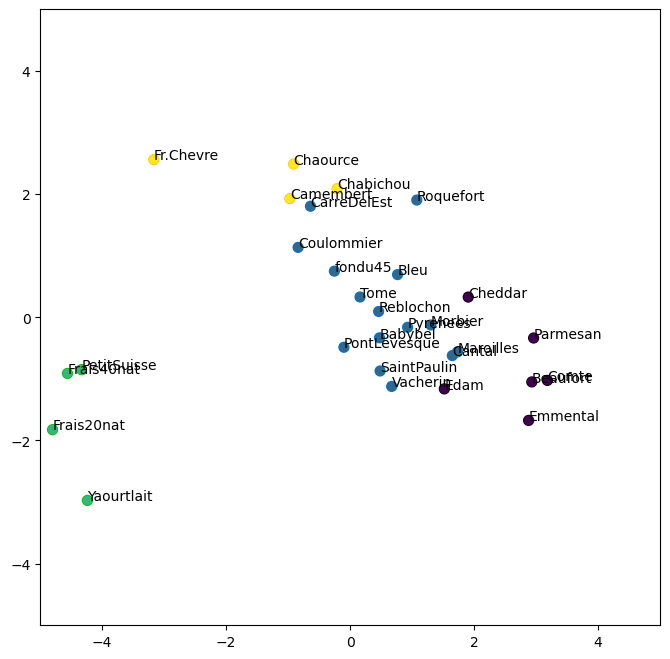

In [179]:
import matplotlib.cm as cm

f,ax = plt.subplots(figsize=(8,8))
#fig, axes = plt.plot(figsize=(12,12))
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
n = coord.shape[0]

colors = cm.nipy_spectral(cluster_labels/4)

# Traçage du nuage de points
for k in range(4):
    is_kth_cluster = (cluster_labels==k)
    ax.scatter(coord[is_kth_cluster,0],coord[is_kth_cluster,1],c=colors[is_kth_cluster],s=50)

n = Z1.shape[0]
for i in range(n):
    plt.annotate(X1.index[i],(coord[i,0],coord[i,1]))
plt.scatter(coord[:,0], coord[:,1], c=cluster_labels)

In [180]:
from sklearn.metrics import davies_bouldin_score
labels=km.labels_
davies_bouldin_score(coord, cluster_labels)
silhouette_score(coord,cluster_labels)

np.float64(0.4725347353908354)

In [90]:
# On peut maintenant caractériser chaque cluster

In [93]:

#moyenne par variable
m = X1.mean()

n=X1.shape[0]
variance = X1.var(ddof=0)

TSS = X1.shape[0]*X1.var(ddof=0)

#data.frame conditionnellement aux groupes
gb = X1.groupby(cluster_labels)

#effectifs conditionnels
nk = gb.size()
print("nk")
print(nk)

#moyennes conditionnelles
mk = gb.mean()

print("mk")
print(mk)

#pour chaque groupe écart à la moyenne par variable
EMk = (mk-m)**2

#pondéré par les effectifs du groupe
EM = EMk.multiply(nk,axis=0)

BSS = np.sum(EM, axis=0)

R2 = BSS/TSS

print("R2")
print(R2)


nk
0     6
1     4
2    15
3     4
dtype: int64
mk
   Calories      Sodium     Calcium    Lipides     Retinol    Folates  \
0    382.00  137.333333  262.866667  29.966667   66.533333   3.416667   
1    276.50  235.500000  127.200000  22.825000  115.000000  34.050000   
2    326.40  276.500000  184.353333  26.960000   58.633333  10.313333   
3    101.75   44.750000  133.750000   6.275000   55.150000  16.475000   

   Proteines  Cholesterol  Magnesium  
0  28.600000   103.333333  42.500000  
1  17.950000    65.000000  24.250000  
2  20.846667    80.666667  25.666667  
3   7.200000    18.250000  11.250000  
R2
Calories       0.888686
Sodium         0.634534
Calcium        0.408980
Lipides        0.868134
Retinol        0.661848
Folates        0.644459
Proteines      0.830104
Cholesterol    0.831532
Magnesium      0.694356
dtype: float64


In [155]:
#On voit des caractéristiques claires de chaque cluster

In [156]:
#On pourrait essayer 6 clusters

In [94]:
km = KMeans(n_clusters=6) 
km.fit(coord) 
km.labels_
cluster_labels = km.predict(coord)
km.inertia_

22.075909535462852

In [95]:
from sklearn.metrics import silhouette_score
score=silhouette_score(coord,cluster_labels)
score

np.float64(0.40399397367884987)

In [97]:
num_clusters=6
sample_silhouette_values = metrics.silhouette_samples(coord, km.labels_)

moy_Score_cluster = []
for i in range(num_clusters):
    moy_Score_cluster.append(sample_silhouette_values[km.labels_ == i].mean())
print(moy_Score_cluster)

[np.float64(0.2751026517186416), np.float64(0.7338388066932793), np.float64(0.43625908138916064), np.float64(0.44493084517183573), np.float64(0.2672527761666209), np.float64(0.3893671948541972)]


In [162]:
from sklearn.metrics import davies_bouldin_score
labels=km.labels_
davies_bouldin_score(coord, cluster_labels)

np.float64(0.6445453876750816)

In [114]:
#moyenne par variable
m = X1.mean()

n=X.shape[0]
variance = X1.var(ddof=0)

TSS = X1.shape[0]*X1.var(ddof=0)

#data.frame conditionnellement aux groupes
gb = X1.groupby(cluster_labels)

#effectifs conditionnels
nk = gb.size()
print("nk")
print(nk)

#moyennes conditionnelles
mk = gb.mean()

print("mk")
print(mk)

#pour chaque groupe écart à la moyenne par variable
EMk = (mk-m)**2

#pondéré par les effectifs du groupe
EM = EMk.multiply(nk,axis=0)

BSS = np.sum(EM, axis=0)

R2 = BSS/TSS

print("R2")
print(R2)

nk
0    7
1    4
2    5
3    4
4    5
5    4
dtype: int64
mk
     Calories      Sodium     Calcium    Lipides     Retinol    Folates  \
0  316.857143  223.142857  193.171429  25.857143   59.028571   5.985714   
1  101.750000   44.750000  133.750000   6.275000   55.150000  16.475000   
2  377.200000  130.400000  278.980000  29.460000   64.560000   3.120000   
3  276.500000  235.500000  127.200000  22.825000  115.000000  34.050000   
4  325.200000  346.700000  138.680000  27.200000   62.640000  19.540000   
5  364.500000  256.000000  225.500000  29.975000   57.375000   5.000000   

   Proteines  Cholesterol  Magnesium  
0  21.214286    77.142857  25.714286  
1   7.200000    18.250000  11.250000  
2  29.120000   102.000000  45.400000  
3  17.950000    65.000000  24.250000  
4  19.440000    82.000000  21.000000  
5  23.250000    92.500000  32.000000  
R2
Calories       0.892094
Sodium         0.745725
Calcium        0.582320
Lipides        0.880116
Retinol        0.655049
Folates        0.

In [163]:
# On va aintenant utiliser CAH. Les 2 librairies (scipy et sklearn) vont être utilisées pour pratique

# La méthode CAH mesure des distances indiquant des similarités entre individus. Le résultat final est le dendrogramme

# le coeff de correlation (c) "cophenic" est la mesure de ressemblance entre individus du fait du clustering. Ce sont ces distances 
# qui sont reliées aux "heights" donc distances donc gain en inertie entre clusters.


0.8639963334208315
[2.71893645 5.01433403 1.79832275 2.33843103 3.44933828 2.53497337
 2.6083605  3.42336294 5.37071782 0.97269247 4.4681343  5.69521587
 4.4667852  1.17565419 5.76883967 5.12167686 3.42195372 2.87336883
 5.23076256 4.88934171 2.45487338 2.61275289 2.44797226 1.76332348
 3.27340283 1.78466132 3.44855979 6.08905789 2.68173585 1.52926588
 2.88154627 1.26632731 2.79635087 3.37978961 1.65088293 3.05648682
 2.05376217 1.85618791 3.16520628 5.20741331 1.59062438 5.49657155
 5.10284805 1.39282613 0.93590148 3.11290919 4.86413729 0.81525935
 0.7321683  0.44003459 2.4717728  0.59637882 0.97921663 0.81319619
 5.40138563 3.36636429 4.91424542 1.79378292 4.45823193 5.2413094
 1.74526816 0.50240132 4.57154922 1.49680586 0.98371148 7.25037097
 4.03873152 7.77824924 7.49271196 1.87763179 2.21737611 1.28651916
 7.27036936 3.36967702 2.57422364 2.81052854 3.86538073 2.51367153
 3.41851992 2.39589418 7.47660493 3.02521201 1.73970973 2.87536731
 3.39146292 1.98750209 3.77339484 1.74156383

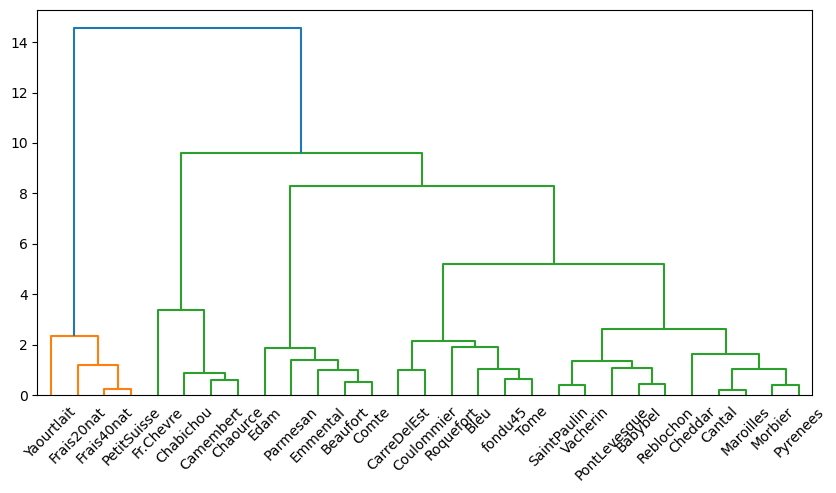

In [184]:
#librairies pour la CAH
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

#générer la matrice des liens
Z = linkage(coord,method='ward')

c, coph_dists = cophenet(Z, pdist(coord))

print(c)
print(pdist(coord))
plt.figure(figsize=(10, 5))

dendrogram(Z,labels=X1.index,orientation='top')

plt.show()

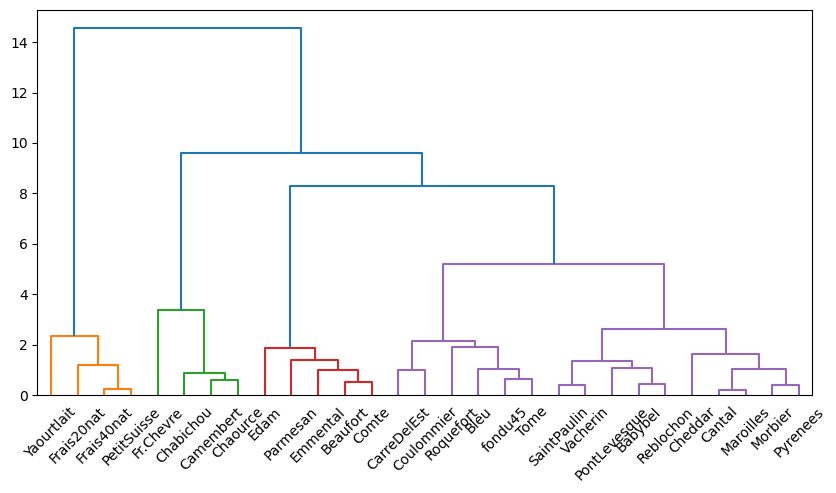

In [102]:
# 2 clusters trouvés automatiquement. On peut regarder si on "coupe" à "height=7", ce qui correspond à la moitié du max.

plt.figure(figsize=(10, 5))
dendrogram(Z,labels=X1.index,orientation='top', color_threshold=7)

plt.show()

In [584]:
# Il serait intéressant d'enlever les fromages frais et de refaire le clustering

In [585]:
# On peut comparer au KMeans

In [586]:
# Autre librairie pour CAH

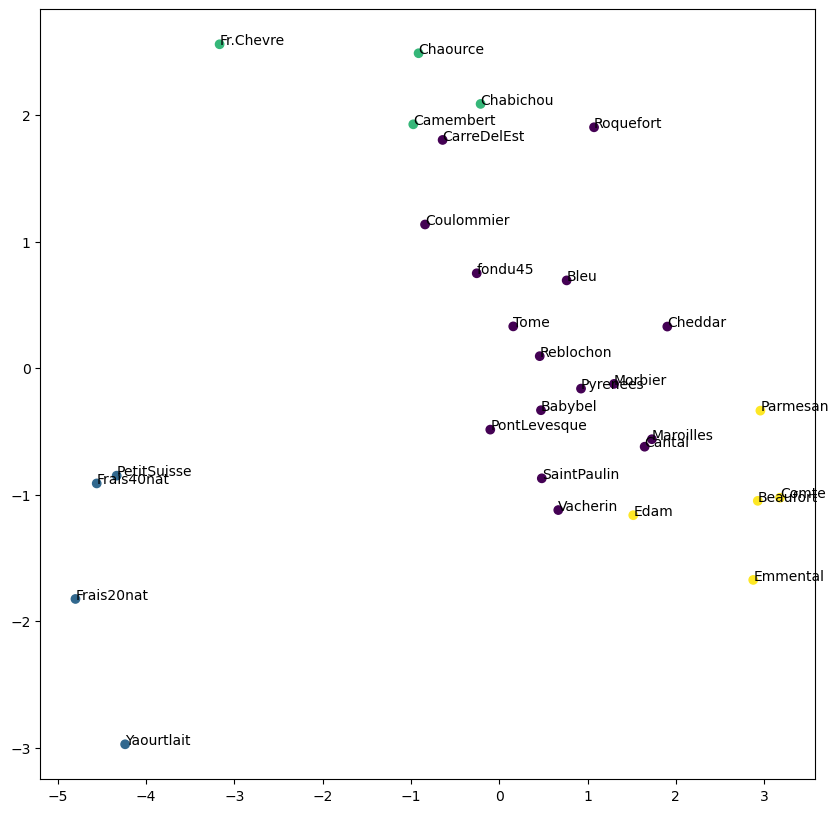

In [108]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=4, linkage='ward')
cluster.fit_predict(coord)
labels=cluster.labels_

plt.figure(figsize=(10, 10))

for k in range(4):
    is_kth_cluster = (cluster_labels==k)
    ax.scatter(coord[is_kth_cluster,0],coord[is_kth_cluster,1],s=50)

n = X1.shape[0]
for i in range(n):
    plt.annotate(X1.index[i],(coord[i,0],coord[i,1]))
plt.scatter(coord[:,0], coord[:,1], c=cluster.labels_)

In [588]:
# On peut tagger les clusters et calculer les métriques de validations

In [109]:
from sklearn.metrics import silhouette_score
score=silhouette_score(coord,labels)
score

np.float64(0.4862292755452435)

In [110]:
# On peut regarder également ici les différences de moyennes des variables initiales dans les clusters

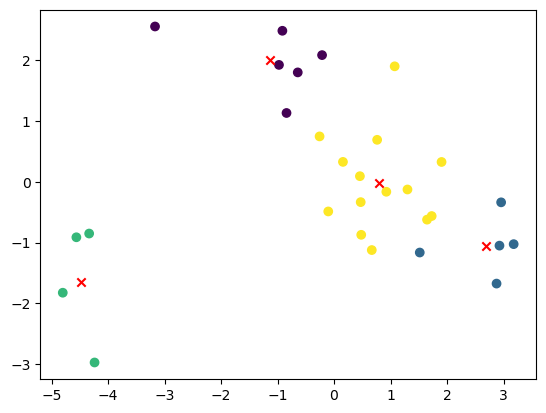

In [112]:
#kmeans2(data, k, iter=10, minit='random', missing='warn', check_finite=True, *, rng=None, seed=None)[source]

import numpy as np
from scipy.cluster.vq import kmeans2, vq, whiten
import matplotlib.pyplot as plt

# Run kmeans2 pour 4 clusters
centroids,distortion = kmeans2(coord, 4,minit='++')

# Assign each observation to a cluster
codes, _  = vq(coord, centroids)

# Plot results
plt.scatter(coord[:, 0], coord[:, 1], c=codes)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x')
plt.show()

In [180]:
# On peut essayer DBSCAN

In [115]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from matplotlib import pyplot as plt
import seaborn as sns

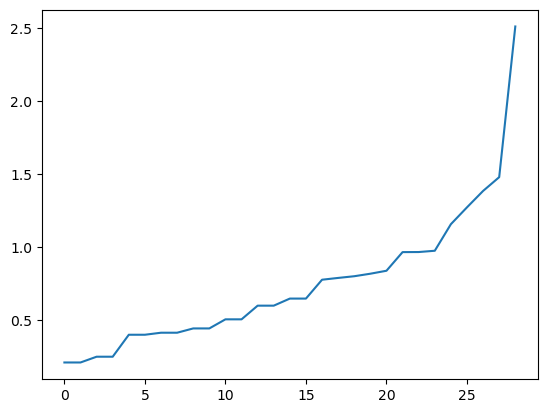

In [116]:
neigh = NearestNeighbors(n_neighbors=6)
nbrs = neigh.fit(coord)
distances, indices = nbrs.kneighbors(coord)


distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

In [129]:
from sklearn.cluster import DBSCAN

In [130]:
outlier_percent = [] 

for eps in np.linspace(1,2): # check 50 values of epsilon between 0.001 and 3
    
    # Create Model
    dbscan = DBSCAN(eps=eps,min_samples=2)
    dbscan.fit(coord)
   
    # Percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
    outlier_percent.append(perc_outliers)
print(perc_outliers)

3.4482758620689653


In [131]:
epsilon = [1.0,1.2,1.3,1.4,1.3,1.4,1.5,1.6,1.7]
min_samples = [2,3,4,5,6]


sil_avg = []
max_value = [0,0,0,0]

for i in range(len(epsilon)):
    for j in range(len(min_samples)):

        db = DBSCAN(min_samples = min_samples[j], eps =epsilon[i]).fit(coord)
        #cluster_labels=dbscan.fit_predict(coord) 
        core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
        core_samples_mask[db.core_sample_indices_] = True
        labels = db.labels_

        # Number of clusters in labels, ignoring noise if present.
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise_ = list(labels).count(-1)


        silhouette_avg = metrics.silhouette_score(coord, labels)
        if silhouette_avg > max_value[3]:
            max_value=(epsilon[i], min_samples[j], n_clusters_, silhouette_avg)
        sil_avg.append(silhouette_avg)

print("epsilon=", max_value[0], 
      "\nmin_sample=", max_value[1],
      "\nnumber of clusters=", max_value[2],
      "\naverage silhouette score= %.4f" % max_value[3])

epsilon= 1.5 
min_sample= 4 
number of clusters= 2 
average silhouette score= 0.4868


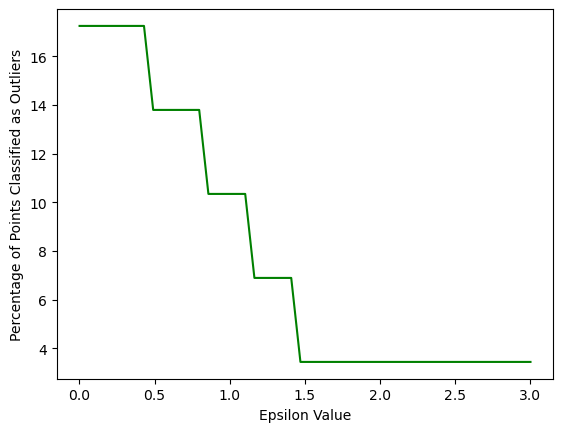

In [132]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent, color='green')
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value");

In [137]:
dbscan = DBSCAN(eps=1.5,min_samples=4)
dbscan.fit(coord)

DBSCAN(eps=1.5, min_samples=4)

In [138]:
dbscan.labels_

array([ 0,  0,  0,  0, -1,  0, -1, -1,  0,  0,  0,  0,  0, -1,  0,  1,  1,
        0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  1])

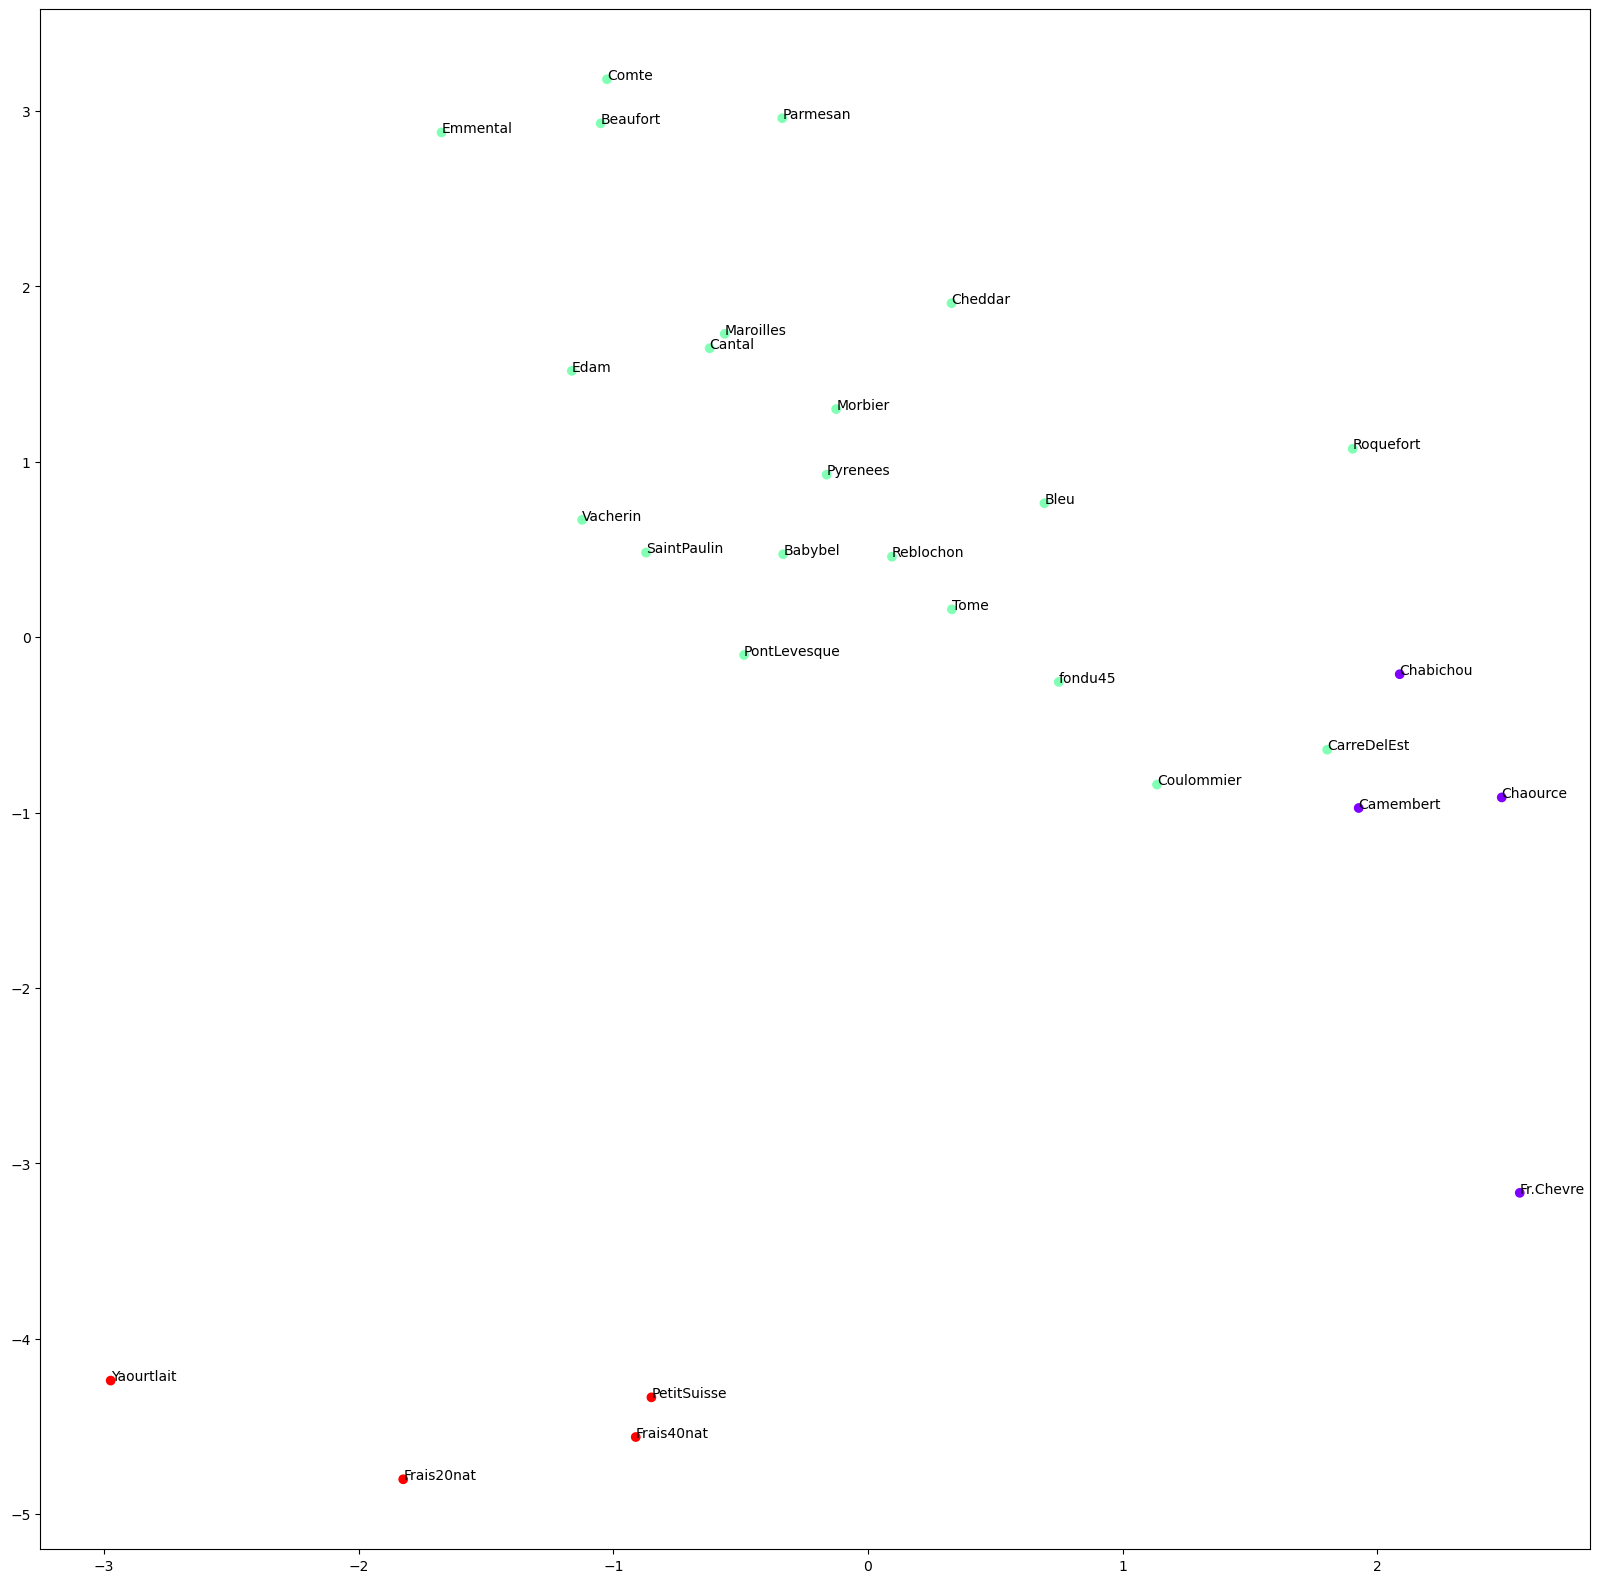

In [145]:
plt.figure(figsize=(20, 20))

n = X1.shape[0]
for i in range(n):
    plt.annotate(X1.index[i],(coord[i,1],coord[i,0]))
plt.scatter(coord[:,1], coord[:,0], c=dbscan.labels_, cmap='rainbow')

In [140]:
# Trop peu d'individus pour que DBSCAN soit intéressant car basé sur des densités de points